In [183]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
    )
from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelBinarizer,LabelEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import  (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

RANDOM_STATE=42

In [184]:
df=pd.read_excel(r"C:\Users\USER\OneDrive\Desktop\AI-Financial-Risk-Intelligence\data\raw\default+of+credit+card+clients\default of credit card clients.xls",header=1)

In [185]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## **EDA**

In [186]:
df.shape
print(f"Dataset have {df.shape[0]} Rows")
print(f"Dataset have {df.shape[1]} Columns")

Dataset have 30000 Rows
Dataset have 25 Columns


In [187]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='str')

In [188]:
## Remove empty columns and normalize accidental whitespace
df=df.dropna(axis=1,how="all")
df.columns = df.columns.astype(str).str.strip()

In [189]:
df.dtypes

ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object

In [190]:
target="default payment next month"
if target not in df.columns:
    raise KeyError(f"Target column not found in given column list {df.columns.tolist()}")

In [191]:
## Convert all columns to numeric where possible
for column in df.columns:
    df[column]=pd.to_numeric(df[column],errors="coerce")

In [192]:
## Feature groups
pay_status_cols=["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
bill_cols=[f"BILL_AMT{i}"for i in range(1,7)]
payment_cols=[f"PAY_AMT{i}"for i in range(1,7)]

In [193]:
numeric_cols=df.select_dtypes(include=np.number).columns.tolist()
feature_cols=[column for column in df.columns if column not in [target,"ID"]]

In [194]:
# -------------------------------------------------------------------
# 2. Feature engineering
# -------------------------------------------------------------------
df["AVG_BILL_AMT"] = df[bill_cols].mean(axis=1)
df["TOTAL_BILL_AMT"] = df[bill_cols].sum(axis=1)
df["AVG_PAY_AMT"] = df[payment_cols].mean(axis=1)
df["TOTAL_PAY_AMT"] = df[payment_cols].sum(axis=1)
df["BILL_VOLATILITY"] = df[bill_cols].std(axis=1)
df["PAYMENT_VOLATILITY"] = df[payment_cols].std(axis=1)
df["MAX_PAYMENT_DELAY"] = df[pay_status_cols].max(axis=1)
df["PAYMENT_DELAY_COUNT"] = (df[pay_status_cols] > 0).sum(axis=1)

In [195]:
df["CREDIT_UTILIZATION"] = np.where(
    df["LIMIT_BAL"] > 0,
    df["AVG_BILL_AMT"] / df["LIMIT_BAL"],
    np.nan,
)
df["PAYMENT_TO_BILL_RATIO"] = np.where(
    df["AVG_BILL_AMT"] > 0,
    df["AVG_PAY_AMT"] / df["AVG_BILL_AMT"],
    np.nan,
)

df["AGE_GROUP"] = pd.cut(
    df["AGE"],
    bins=[0, 25, 35, 45, 55, 65, np.inf],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"],
)
df["LIMIT_BAL_GROUP"] = pd.qcut(
    df["LIMIT_BAL"],
    q=5,
    duplicates="drop",
)

def risk_band(probability):
    if probability >= 0.50:
        return "HIGH"
    if probability >= 0.25:
        return "MEDIUM"
    return "LOW"


## 1. Dataset Understanding

1. How many rows and columns does the dataset contain?
2. What does each column represent?
3. What is the target column?
4. Are `ID` values unique?
5. Are there duplicate records?
6. Are column names correctly loaded?
7. What are the data types of all columns?
8. Are there unnamed or unnecessary columns?
9. Is the dataset loaded without shifted headers or missing rows?

In [196]:
answers = {}

In [197]:
answers[1] = f"Rows: {df.shape[0]}, Columns: {df.shape[1]}"
answers[2] = {
    "ID": "Customer identifier",
    "LIMIT_BAL": "Credit limit",
    "SEX": "Gender code",
    "EDUCATION": "Education code",
    "MARRIAGE": "Marital-status code",
    "AGE": "Customer age",
    "PAY_*": "Repayment status for previous months",
    "BILL_AMT*": "Statement bill amount",
    "PAY_AMT*": "Previous payment amount",
    target: "Default indicator: 0 = no default, 1 = default",
}
answers[3] = f"Target column: {target}"
answers[4] = f"Unique IDs: {df['ID'].nunique()} / {len(df)}"
answers[5] = f"Duplicate rows: {df.duplicated().sum()}"
answers[6] = f"Columns loaded correctly: {list(df.columns)}"
answers[7] = df.dtypes.astype(str).to_dict()
answers[8] = f"Unnamed columns: {[c for c in df.columns if c.lower().startswith('unnamed')]}"
answers[9] = (
    f"Header/data validation: {df.shape[1]} columns loaded; "
    f"first data row index is {df.index[0]}"
)

## 2. Data Quality

10. How many missing values exist in each column?
11. Are missing values represented as `0`, `-1`, or special codes?
12. Are there duplicated rows?
13. Are any columns constant or nearly constant?
14. Are numerical columns stored using the correct data type?
15. Are categorical values valid?
16. Are there negative values where they should not exist?
17. Are there impossible ages, balances, payments, or bill amounts?
18. Are there inconsistent category values?
19. Are there data-entry errors?

In [198]:
answers[10] = df.isna().sum().sort_values(ascending=False).to_dict()
# answers[11] = {
#     "zero_values": df.eq(0).sum().sort_values(ascending=False).head(10).to_dict(),
#     "negative_values": df.lt(0).sum().sort_values(ascending=False).head(10).to_dict(),
# }
answers[12] = f"Duplicated rows: {df.duplicated().sum()}"
answers[13] = df.nunique().sort_values().head(10).to_dict()
answers[14] = df.dtypes.astype(str).to_dict()
answers[15] = {
    column: sorted(df[column].dropna().unique().tolist())
    for column in ["SEX", "EDUCATION", "MARRIAGE"]
}
answers[16] = {
    column: int(df[column].lt(0).sum())
    for column in ["LIMIT_BAL", "AGE"] + bill_cols + payment_cols
}
answers[17] = {
    "invalid_age": int((~df["AGE"].between(18, 100)).sum()),
    "invalid_limit": int((df["LIMIT_BAL"] < 0).sum()),
    "invalid_target": int((~df[target].isin([0, 1])).sum()),
}
answers[18] = {
    column: df[column].value_counts(dropna=False).to_dict()
    for column in ["SEX", "EDUCATION", "MARRIAGE"]
}
answers[19] = (
    "Potential data-quality issues are shown in answers 10–18. "
    "Investigate special category codes before modeling."
)

In [199]:
{
    # "zero_values": df.eq(0).sum().sort_values(ascending=False).head(10).to_dict(),
    # "negative_values": df.lt(0).sum().sort_values(ascending=False).head(10).to_dict(),
}

{}

## 3. Target Variable

20. What is the distribution of `default.payment.next.month`?
21. How many customers defaulted?
22. How many customers did not default?
23. Is the target dataset imbalanced?
24. What is the default percentage?
25. Are there suspicious or invalid target values?
26. Is the target suitable for binary classification?

In [200]:
target_counts = df[target].value_counts(dropna=False)
target_rates = df[target].value_counts(normalize=True, dropna=False) * 100

answers[20] = target_counts.to_dict()
answers[21] = int((df[target] == 1).sum())
answers[22] = int((df[target] == 0).sum())
answers[23] = f"Class imbalance ratio: {target_rates.get(0, 0):.2f}% no default / {target_rates.get(1, 0):.2f}% default"
answers[24] = f"Default percentage: {target_rates.get(1, 0):.2f}%"
answers[25] = f"Invalid target values: {int((~df[target].isin([0, 1])).sum())}"
answers[26] = "Yes. The target is suitable for binary classification after validation."


## 4. Numerical Feature Analysis

27. What are the minimum, maximum, mean, median, and standard deviation of each numerical column?
28. Which variables are highly skewed?
29. Which variables contain extreme outliers?
30. What is the distribution of `LIMIT_BAL`?
31. What is the distribution of `AGE`?
32. What is the distribution of bill amounts?
33. What is the distribution of previous payment amounts?
34. Are there unusually large credit limits?
35. Are there customers with zero bill amounts?
36. Are there customers with zero payment amounts?
37. Are any features strongly concentrated around one value?

In [201]:
base_numeric = [
    "LIMIT_BAL",
    "AGE",
    *pay_status_cols,
    *bill_cols,
    *payment_cols,
]

answers[27] = df[base_numeric].describe().T.round(2).to_dict("index")
skewness = df[base_numeric].skew().sort_values(key=abs, ascending=False)
answers[28] = skewness.round(3).to_dict()


In [202]:
outlier_counts = {}
for column in base_numeric:
    q1, q3 = df[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    outlier_counts[column] = int(
        ((df[column] < q1 - 1.5 * iqr) | (df[column] > q3 + 1.5 * iqr)).sum()
    )

In [203]:
answers[29] = dict(sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True))
answers[30] = df["LIMIT_BAL"].describe().round(2).to_dict()
answers[31] = df["AGE"].describe().round(2).to_dict()
answers[32] = df[bill_cols].describe().T.round(2).to_dict("index")
answers[33] = df[payment_cols].describe().T.round(2).to_dict("index")
answers[34] = f"Maximum credit limit: {df['LIMIT_BAL'].max():,.2f}"
answers[35] = {column: int((df[column] == 0).sum()) for column in bill_cols}
answers[36] = {column: int((df[column] == 0).sum()) for column in payment_cols}
answers[37] = df[base_numeric].nunique().sort_values().head(10).to_dict()


## 5. Categorical Feature Analysis

38. What are the unique values of `SEX`?
39. What are the unique values of `EDUCATION`?
40. What are the unique values of `MARRIAGE`?
41. What are the unique values of each `PAY_*` column?
42. Are there undocumented category codes?
43. Are any categories extremely rare?
44. Should invalid categories be grouped as `"Unknown"`?
45. Is one category dominant?

In [204]:
answers[38] = df["SEX"].value_counts(dropna=False).to_dict()
answers[39] = df["EDUCATION"].value_counts(dropna=False).to_dict()
answers[40] = df["MARRIAGE"].value_counts(dropna=False).to_dict()
answers[41] = {
    column: df[column].value_counts(dropna=False).to_dict()
    for column in pay_status_cols
}
answers[42] = {
    "education_unusual_codes": sorted(set(df["EDUCATION"].dropna().unique()) - {0, 1, 2, 3, 4, 5, 6}),
    "marriage_unusual_codes": sorted(set(df["MARRIAGE"].dropna().unique()) - {0, 1, 2, 3}),
}
answers[43] = {
    column: df[column].value_counts(normalize=True).min()
    for column in ["SEX", "EDUCATION", "MARRIAGE"]
}
answers[44] = "Unknown or undocumented category codes should be grouped after domain validation."
answers[45] = {
    column: df[column].value_counts(normalize=True).max().round(3)
    for column in ["SEX", "EDUCATION", "MARRIAGE"]
}

## 6. Credit-Limit Analysis

46. Does default rate change with `LIMIT_BAL`?
47. Do customers with lower credit limits default more often?
48. What is the relationship between credit limit and age?
49. What is the relationship between credit limit and education?
50. Are credit limits different between male and female customers?
51. Are credit limits different between married and unmarried customers?

In [205]:
def default_rate_by(column):
    return (
        df.groupby(column, observed=True)[target]
        .agg(["count", "sum", "mean"])
        .rename(columns={"sum": "defaults", "mean": "default_rate"})
        .assign(default_rate=lambda x: (x["default_rate"] * 100).round(2))
        .round(2)
    )


In [206]:
answers[46] = default_rate_by("LIMIT_BAL_GROUP").to_dict("index")
answers[47] = (
    f"Lowest credit-limit group default rate: "
    f"{default_rate_by('LIMIT_BAL_GROUP')['default_rate'].min():.2f}%"
)
answers[48] = df[["LIMIT_BAL", "AGE"]].corr().iloc[0, 1].round(3)
answers[49] = df.groupby("EDUCATION", observed=True)["LIMIT_BAL"].mean().round(2).to_dict()
answers[50] = df.groupby("SEX", observed=True)["LIMIT_BAL"].mean().round(2).to_dict()
answers[51] = df.groupby("MARRIAGE", observed=True)["LIMIT_BAL"].mean().round(2).to_dict()


## 7. Demographic Analysis

52. Does default rate vary by `SEX`?
53. Does default rate vary by `EDUCATION`?
54. Does default rate vary by `MARRIAGE`?
55. Does default rate vary by age group?
56. Which age group has the highest default rate?
57. Are demographic categories balanced?
58. Are there interactions between age, education, marriage, and default?

In [207]:
answers[52] = default_rate_by("SEX").to_dict("index")
answers[53] = default_rate_by("EDUCATION").to_dict("index")
answers[54] = default_rate_by("MARRIAGE").to_dict("index")
answers[55] = default_rate_by("AGE_GROUP").to_dict("index")
answers[56] = default_rate_by("AGE_GROUP")["default_rate"].idxmax()
answers[57] = {
    column: df[column].value_counts().to_dict()
    for column in ["SEX", "EDUCATION", "MARRIAGE", "AGE_GROUP"]
}
answers[58] = (
    df.groupby(["SEX", "EDUCATION", "MARRIAGE"], observed=True)[target]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .head(10)
    .to_dict()
)


## 8. Repayment-Status Analysis

59. What does each `PAY_*` column represent?
60. What is the distribution of each repayment-status column?
61. Does late repayment increase default probability?
62. Which repayment month is most predictive?
63. Does repeated late payment indicate higher risk?
64. Are repayment-status columns correlated?
65. Are there customers with consistently negative repayment-status values?
66. Does the most recent repayment status have stronger predictive power?

In [208]:
answers[59] = "PAY_0 and PAY_2–PAY_6 represent repayment status for previous months."
answers[60] = {column: df[column].describe().round(2).to_dict() for column in pay_status_cols}
answers[61] = {
    column: df.groupby(column, observed=True)[target].mean().mul(100).round(2).to_dict()
    for column in pay_status_cols
}
answers[62] = (
    df[pay_status_cols].corrwith(df[target])
    .abs()
    .sort_values(ascending=False)
    .index[0]
)
answers[63] = default_rate_by("PAYMENT_DELAY_COUNT").head(10).to_dict("index")
answers[64] = df[pay_status_cols].corr().round(3).to_dict()
answers[65] = {
    column: int((df[column] < 0).sum())
    for column in pay_status_cols
}
answers[66] = (
    df.groupby("PAY_0", observed=True)[target]
    .mean()
    .mul(100)
    .round(2)
    .to_dict()
)

## 9. Bill-Amount Analysis

67. What is the average bill amount for each month?
68. Does the bill amount trend increase or decrease over time?
69. Does a high bill amount increase default probability?
70. Are bill amounts related to credit limit?
71. Are there customers whose bill exceeds their credit limit?
72. What is the monthly bill volatility?
73. Are there months with unusual bill distributions?

In [209]:
answers[67] = df[bill_cols].mean().round(2).to_dict()
answers[68] = {
    "monthly_mean": df[bill_cols].mean().round(2).to_dict(),
    "monthly_change": df[bill_cols].mean().diff().round(2).to_dict(),
}
answers[69] = default_rate_by("LIMIT_BAL_GROUP").to_dict("index")
answers[70] = df[["LIMIT_BAL", *bill_cols]].corr()["LIMIT_BAL"].round(3).to_dict()
answers[71] = {
    column: int((df[column] > df["LIMIT_BAL"]).sum())
    for column in bill_cols
}
answers[72] = df["BILL_VOLATILITY"].describe().round(2).to_dict()
answers[73] = df[bill_cols].mean().idxmax()



## 10. Payment-Amount Analysis

74. What is the average payment amount for each month?
75. Does payment amount vary by default status?
76. Are customers making payments consistently?
77. Does a low payment-to-bill ratio indicate default risk?
78. Are payment amounts zero for many customers?
79. Are there unusually large payment values?
80. Does payment behavior change over time?

In [210]:
answers[74] = df[payment_cols].mean().round(2).to_dict()
answers[75] = {
    column: df.groupby(target)[column].mean().round(2).to_dict()
    for column in payment_cols
}
answers[76] = {
    "zero_payment_count": int((df[payment_cols] == 0).all(axis=1).sum()),
    "average_active_payment_months": (df[payment_cols] > 0).sum(axis=1).mean().round(2),
}
answers[77] = default_rate_by("LIMIT_BAL_GROUP").to_dict("index")
answers[78] = {
    column: int((df[column] == 0).sum())
    for column in payment_cols
}
answers[79] = {
    column: float(df[column].max())
    for column in payment_cols
}
answers[80] = df[payment_cols].mean().diff().round(2).to_dict()


## 11. Feature Relationships

81. Which features are strongly correlated?
82. Are bill-amount columns highly correlated with one another?
83. Are payment-amount columns highly correlated with one another?
84. Are bill amounts and payment amounts correlated?
85. Is `LIMIT_BAL` correlated with bill amounts?
86. Are there multicollinearity problems?
87. Which features have the strongest relationship with the target?
88. Are relationships linear or nonlinear?

In [211]:
correlation_matrix = df[base_numeric + [target]].corr()
target_correlations = correlation_matrix[target].drop(target).sort_values(
    key=abs,
    ascending=False,
)

In [212]:
answers[81] = correlation_matrix.round(3).to_dict()
answers[82] = df[bill_cols].corr().round(3).to_dict()
answers[83] = df[payment_cols].corr().round(3).to_dict()
answers[84] = df[bill_cols + payment_cols].corr().round(3).to_dict()
answers[85] = df[["LIMIT_BAL", *bill_cols]].corr()["LIMIT_BAL"].round(3).to_dict()
answers[86] = (
    correlation_matrix.drop(columns=[target], errors="ignore")
    .stack()
    .loc[lambda x: abs(x) >= 0.80]
    .sort_values(key=abs, ascending=False)
    .head(20)
    .to_dict()
)
answers[87] = target_correlations.head(15).round(3).to_dict()
answers[88] = (
    "Pearson correlations are shown in answers 81–87. "
    "Use plots and tree models to investigate nonlinear relationships."
)

## 12. Default-Based Comparisons

89. How do defaulted and non-defaulted customers differ?
90. Is the average credit limit different between the two groups?
91. Is the average age different between the two groups?
92. Are bill amounts higher for defaulted customers?
93. Are payment amounts lower for defaulted customers?
94. Are late-payment statuses more common among defaulters?
95. Which demographic groups have the largest default-rate difference?
96. Which features show the clearest separation between target classes?

In [213]:
answers[89] = df.groupby(target)[base_numeric].mean().round(2).to_dict("index")
answers[90] = df.groupby(target)["LIMIT_BAL"].mean().round(2).to_dict()
answers[91] = df.groupby(target)["AGE"].mean().round(2).to_dict()
answers[92] = df.groupby(target)[bill_cols].mean().round(2).to_dict("index")
answers[93] = df.groupby(target)[payment_cols].mean().round(2).to_dict("index")
answers[94] = df.groupby(target)[pay_status_cols].mean().round(2).to_dict("index")
answers[95] = {
    column: default_rate_by(column)["default_rate"].sub(
        default_rate_by(column)["default_rate"].min()
    ).round(2).to_dict()
    for column in ["SEX", "EDUCATION", "MARRIAGE", "AGE_GROUP"]
}
answers[96] = target_correlations.head(10).round(3).to_dict()


## 13. Grouped Risk Analysis

97. What is the default rate by credit-limit range?
98. What is the default rate by age group?
99. What is the default rate by education level?
100. What is the default rate by marriage status?
101. What is the default rate by repayment-status category?
102. What is the default rate for customers with zero payments?
103. What is the default rate for customers with repeated late payments?
104. Which customer segment is highest risk?
105. Which combination of features identifies high-risk customers?

In [214]:
answers[97] = default_rate_by("LIMIT_BAL_GROUP").to_dict("index")
answers[98] = default_rate_by("AGE_GROUP").to_dict("index")
answers[99] = default_rate_by("EDUCATION").to_dict("index")
answers[100] = default_rate_by("MARRIAGE").to_dict("index")
answers[101] = {
    column: default_rate_by(column).to_dict("index")
    for column in pay_status_cols
}
answers[102] = (
    f"Default rate when all payments are zero: "
    f"{df.loc[(df[payment_cols] == 0).all(axis=1), target].mean() * 100:.2f}%"
)

In [215]:
answers[103] = (
    df.loc[df["PAYMENT_DELAY_COUNT"] >= 3, target].mean() * 100
).round(2)
answers[104] = {
    "highest_demographic_group": {
        "education": default_rate_by("EDUCATION")["default_rate"].idxmax(),
        "marriage": default_rate_by("MARRIAGE")["default_rate"].idxmax(),
        "age_group": default_rate_by("AGE_GROUP")["default_rate"].idxmax(),
    },
    "highest_repayment_status": {
        column: default_rate_by(column)["default_rate"].idxmax()
        for column in pay_status_cols
    },
}
answers[105] = (
    df.groupby(["PAYMENT_DELAY_COUNT", "AGE_GROUP"], observed=True)[target]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .head(10)
    .to_dict()
)

## 14. Outlier and Anomaly Analysis

106. Which columns contain statistical outliers?
107. Are outliers genuine financial values or data errors?
108. Do outliers disproportionately belong to defaulted customers?
109. Should outliers be removed, capped, transformed, or retained?
110. Are there customers with impossible financial relationships?
111. Are there duplicate customers with conflicting values?

In [216]:
answers[106] = {
    column: count
    for column, count in answers[29].items()
    if count > 0
}
answers[107] = (
    "Outliers require domain review. Financial extremes should usually be retained "
    "or transformed rather than blindly removed."
)

In [217]:
answers[108] = {
    "default_rate_outliers": {
        column: (
            df.loc[
                (
                    (df[column] < df[column].quantile(0.25) -
                     1.5 * (df[column].quantile(0.75) - df[column].quantile(0.25)))
                    |
                    (df[column] > df[column].quantile(0.75) +
                     1.5 * (df[column].quantile(0.75) - df[column].quantile(0.25)))
                ),
                target,
            ].mean() * 100
        ).round(2)
        for column in ["LIMIT_BAL", "AGE", *bill_cols, *payment_cols]
    }
}

In [218]:
answers[109] = (
    "Recommended treatment: validate, cap or transform heavily skewed values; "
    "do not remove genuine financial observations without justification."
)
answers[110] = {
    "bill_above_limit": int((df[bill_cols].gt(df["LIMIT_BAL"], axis=0)).any(axis=1).sum()),
    "negative_age": int((df["AGE"] < 0).sum()),
    "negative_limit": int((df["LIMIT_BAL"] < 0).sum()),
}
answers[111] = {
    "duplicate_ids": int(df["ID"].duplicated().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
}


## 15. Modeling Preparation

112. Which columns should be removed?
113. Should `ID` be excluded from modeling?
114. Which columns are numerical?
115. Which columns are categorical?
116. Which columns require encoding?
117. Which columns require scaling?
118. Are missing values present after cleaning?
119. Is class imbalance severe enough to require special handling?
120. Should stratified train-test splitting be used?
121. Could any feature cause target leakage?
122. Should correlated features be removed?
123. Should derived features be created?

In [219]:
answers[112] = ["ID", target]
answers[113] = "Yes. Exclude ID from model features because it is an identifier."
answers[114] = df[feature_cols].select_dtypes(include=np.number).columns.tolist()
answers[115] = ["SEX", "EDUCATION", "MARRIAGE"]
answers[116] = "Encode categorical columns if treated as nominal categories."
answers[117] = (
    "Scale continuous features for linear models; tree-based models generally "
    "do not require scaling."
)
answers[118] = df[feature_cols].isna().sum().sum()
answers[119] = f"Minority/default rate: {target_rates.get(1, 0):.2f}%; use stratification and PR-AUC."
answers[120] = "Yes. Use stratified train-test splitting."
answers[121] = (
    "Check that derived features use only information available before the prediction date. "
    "Do not use future or post-default information."
)
answers[122] = (
    "Do not automatically remove correlated features for tree models; "
    "inspect multicollinearity for linear models."
)

answers[123] = [
    "AVG_BILL_AMT",
    "TOTAL_BILL_AMT",
    "AVG_PAY_AMT",
    "TOTAL_PAY_AMT",
    "CREDIT_UTILIZATION",
    "PAYMENT_TO_BILL_RATIO",
    "PAYMENT_DELAY_COUNT",
    "MAX_PAYMENT_DELAY",
    "BILL_VOLATILITY",
]


## 16. Useful Derived Features

124. Can a debt-to-limit ratio be calculated?
125. Can a payment-to-bill ratio be calculated?
126. Can average bill amount be calculated?
127. Can average payment amount be calculated?
128. Can total bill amount be calculated?
129. Can total payment amount be calculated?
130. Can repayment delay count be calculated?
131. Can maximum repayment delay be calculated?
132. Can bill-payment volatility be calculated?
133. Can credit-utilization groups be created?
134. Can customers be grouped into low-, medium-, and high-risk segments?


In [220]:
answers[124] = "CREDIT_UTILIZATION = AVG_BILL_AMT / LIMIT_BAL"
answers[125] = "PAYMENT_TO_BILL_RATIO = AVG_PAY_AMT / AVG_BILL_AMT"
answers[126] = "AVG_BILL_AMT created"
answers[127] = "AVG_PAY_AMT created"
answers[128] = "TOTAL_BILL_AMT created"
answers[129] = "TOTAL_PAY_AMT created"
answers[130] = "PAYMENT_DELAY_COUNT created"
answers[131] = "MAX_PAYMENT_DELAY created"
answers[132] = "BILL_VOLATILITY and PAYMENT_VOLATILITY created"
answers[133] = (
    f"Credit-utilization statistics: {df['CREDIT_UTILIZATION'].describe().round(2).to_dict()}"
)
answers[134] = {
    band: int((df["PAYMENT_DELAY_COUNT"].apply(
        lambda x: "HIGH" if x >= 3 else "MEDIUM" if x >= 1 else "LOW"
    ) == band).sum())
    for band in ["LOW", "MEDIUM", "HIGH"]
}



## 17. Final EDA Conclusions

135. What are the main characteristics of the dataset?
136. Is the dataset suitable for credit-default prediction?
137. What are the main data-quality problems?
138. Which variables are most important for further modeling?
139. What preprocessing steps are required?
140. What business insights were discovered?
141. What risks or limitations exist in the dataset?
142. Are the results suitable for decision support with human review?

**Important:** Use `ID` only for identification and exclude it from model features. The target column in this dataset is typically `default.payment.next.month`; verify the exact name after loading the Excel file.

In [221]:
answers[135] = {
    "rows": len(df),
    "columns": len(df.columns),
    "default_rate": f"{df[target].mean() * 100:.2f}%",
    "missing_values": int(df.isna().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
}
answers[136] = (
    "Yes. The dataset is suitable for credit-default classification after cleaning, "
    "validation, feature engineering, and imbalance handling."
)
answers[137] = {
    "missing_values": int(df.isna().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "invalid_target_values": int((~df[target].isin([0, 1])).sum()),
    "duplicate_ids": int(df["ID"].duplicated().sum()),
}

In [222]:
answers[138] = target_correlations.abs().sort_values(ascending=False).head(10).round(3).to_dict()
answers[139] = [
    "Validate category codes",
    "Handle missing values",
    "Exclude ID",
    "Create derived features",
    "Encode categorical features",
    "Use stratified splitting",
    "Evaluate imbalance with PR-AUC, recall, precision, and F1",
]
answers[140] = (
    "Investigate repayment delays, payment-to-bill behavior, utilization, "
    "credit limit, and customer demographics as risk indicators."
)

In [223]:
answers[141] = [
    "Dataset may not represent every population",
    "Category codes require domain interpretation",
    "Class imbalance can affect accuracy",
    "Correlation does not prove causation",
    "Predictions require human review",
]
answers[142] = (
    "Yes, for decision support after validation. It must not be used as an "
    "automatic loan approval, rejection, fraud, or legal-compliance authority."
)


In [224]:
# for number in range(1, 143):
#     print(f"\n{'=' * 80}\nQ{number}.")
#     print(answers[number])


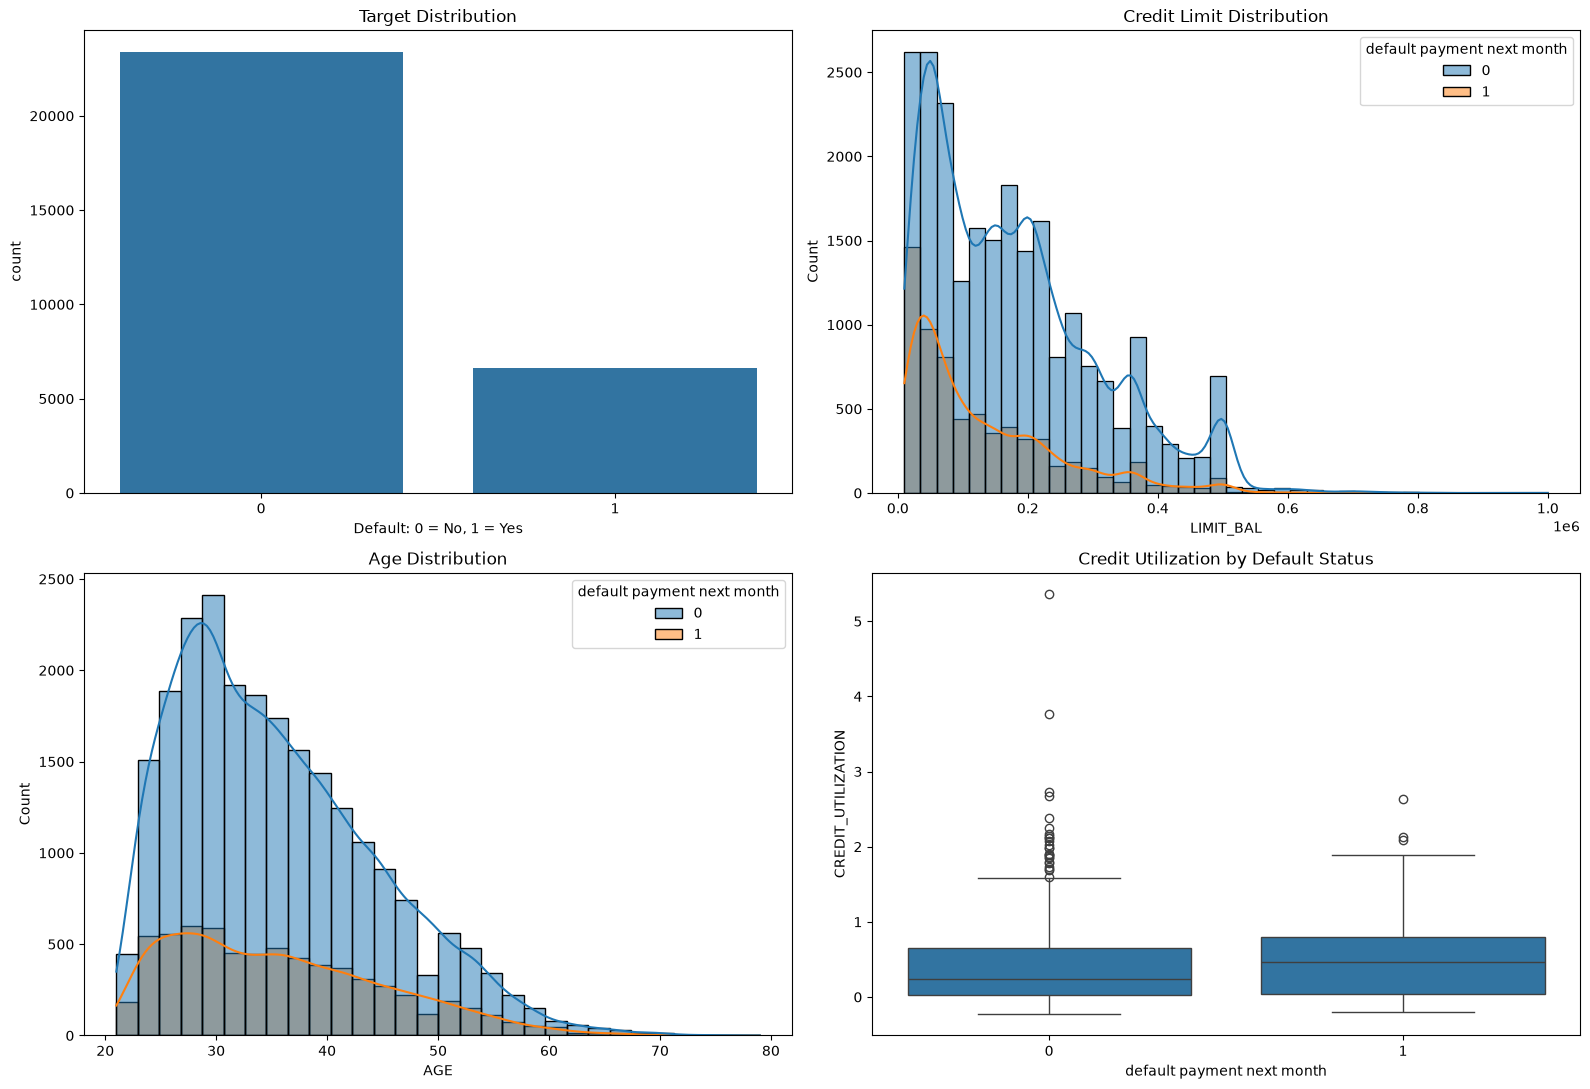

In [225]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.countplot(data=df, x=target, ax=axes[0, 0])
axes[0, 0].set_title("Target Distribution")
axes[0, 0].set_xlabel("Default: 0 = No, 1 = Yes")

sns.histplot(data=df, x="LIMIT_BAL", hue=target, kde=True, bins=40, ax=axes[0, 1])
axes[0, 1].set_title("Credit Limit Distribution")

sns.histplot(data=df, x="AGE", hue=target, kde=True, bins=30, ax=axes[1, 0])
axes[1, 0].set_title("Age Distribution")

sns.boxplot(data=df, x=target, y="CREDIT_UTILIZATION", ax=axes[1, 1])
axes[1, 1].set_title("Credit Utilization by Default Status")

plt.tight_layout()
plt.show()


## `Correlation heatmap`

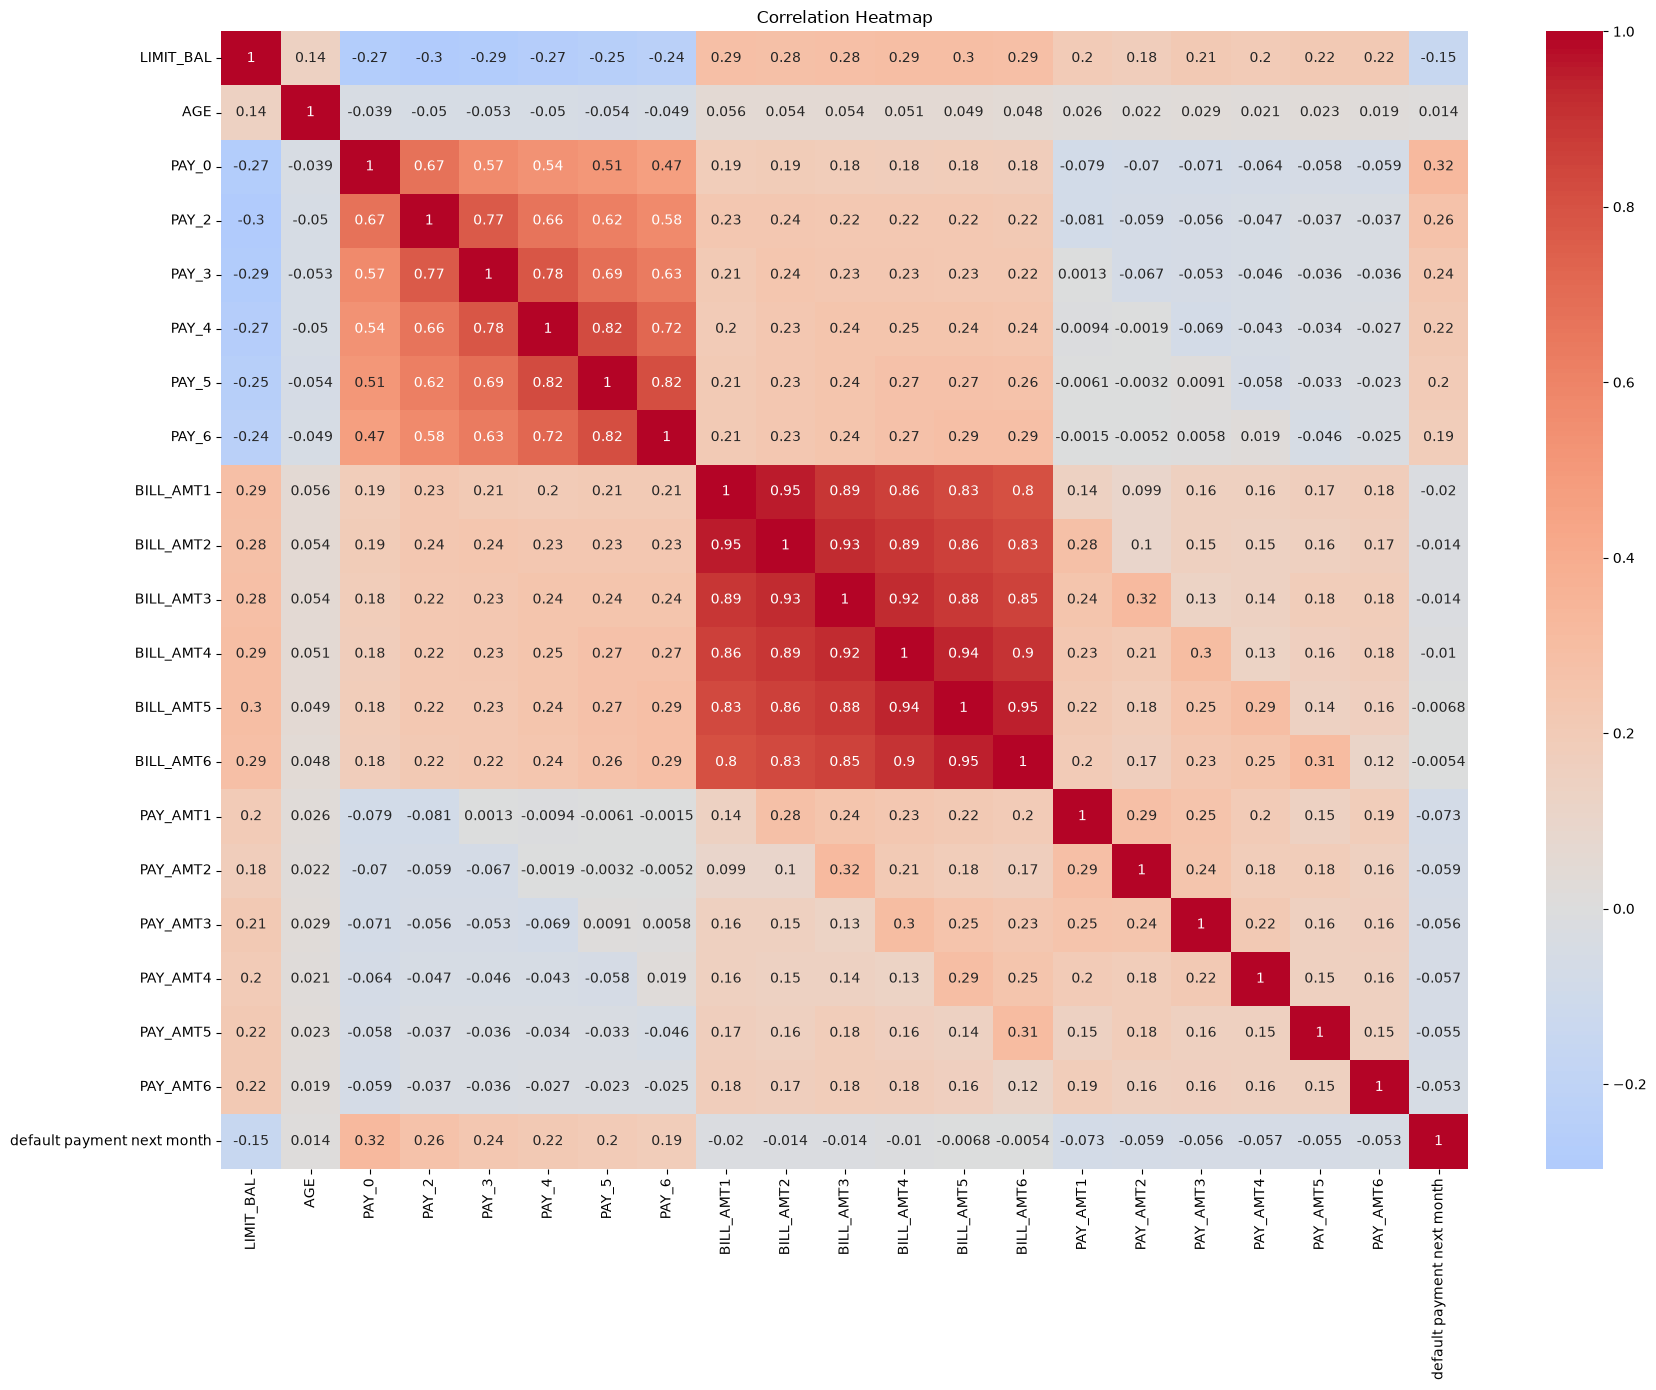

In [226]:
plt.figure(figsize=(18, 14))
sns.heatmap(
    df[base_numeric + [target]].corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## `Default rate by repayment status`

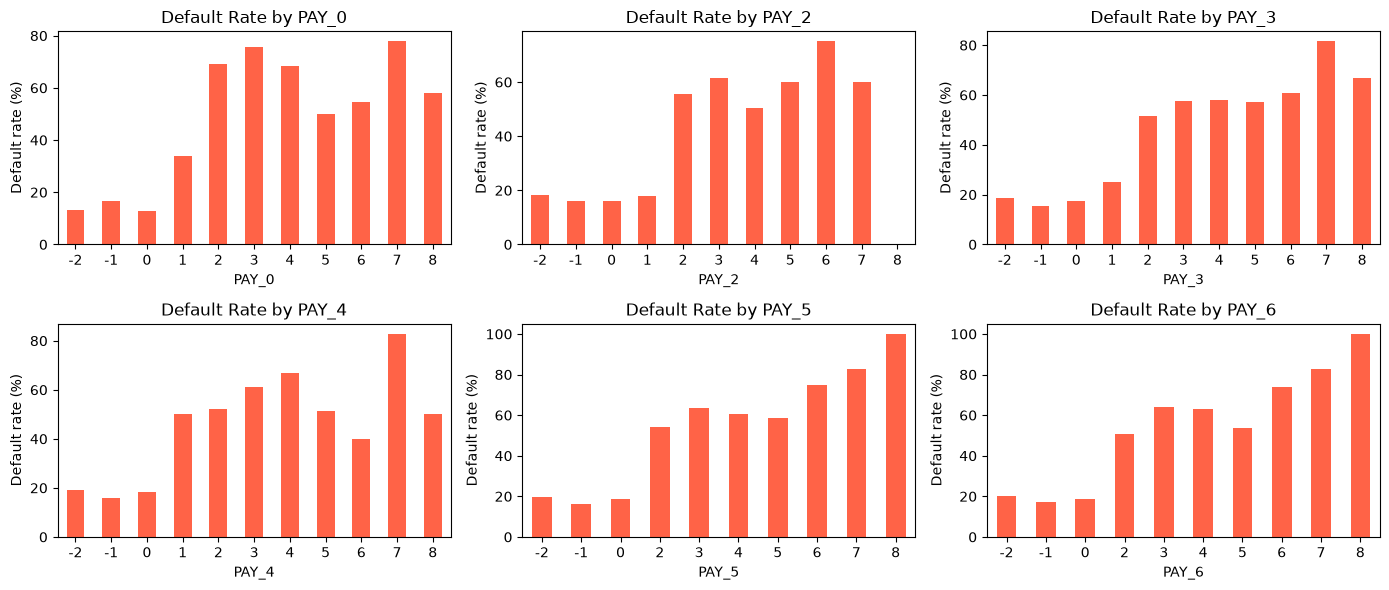

In [227]:
plt.figure(figsize=(14, 6))
for index, column in enumerate(pay_status_cols, start=1):
    grouped = df.groupby(column, observed=True)[target].mean().mul(100)
    plt.subplot(2, 3, index)
    grouped.plot(kind="bar", color="tomato")
    plt.title(f"Default Rate by {column}")
    plt.ylabel("Default rate (%)")
    plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## `Default rate by important groups`

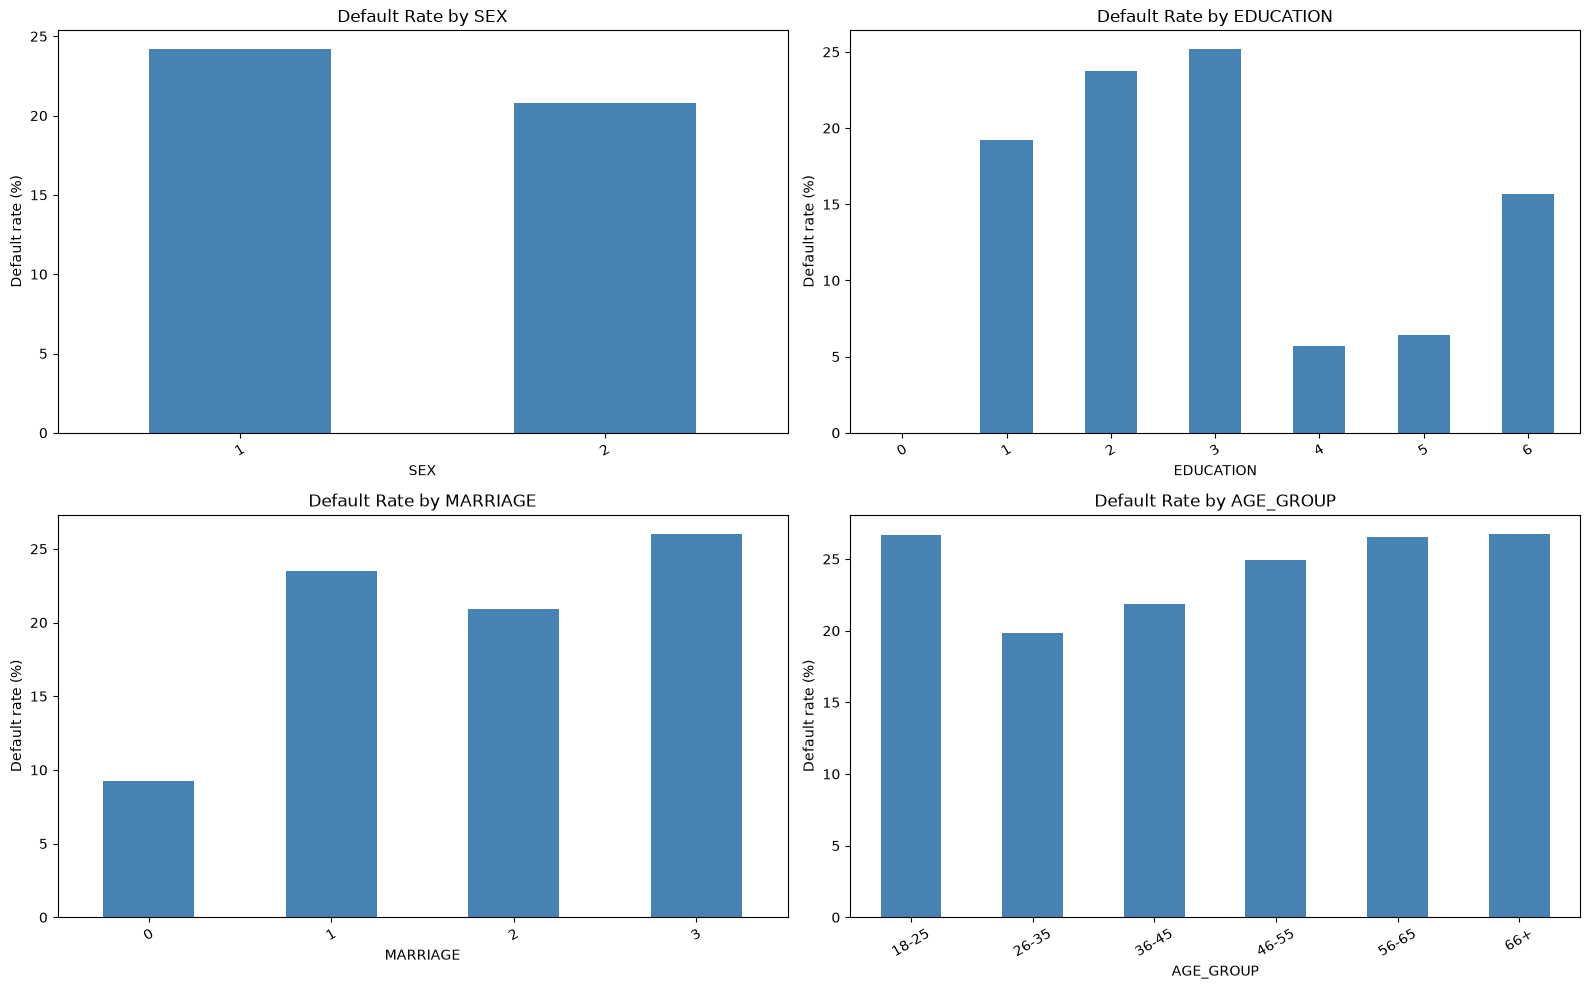

In [228]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for axis, column in zip(
    axes.ravel(),
    ["SEX", "EDUCATION", "MARRIAGE", "AGE_GROUP"],
):
    grouped = df.groupby(column, observed=True)[target].mean().mul(100)
    grouped.plot(kind="bar", ax=axis, color="steelblue")
    axis.set_title(f"Default Rate by {column}")
    axis.set_ylabel("Default rate (%)")
    axis.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## **Model Building for Credit-Default Model**
compares multiple modeling scenarios, uses stratified cross-validation, evaluates several metrics, tunes decision thresholds, and selects a model while reducing overfitting risk

In [229]:
model_df=df.drop(columns=["ID"]).copy()

In [230]:
# Convert AGE_GROUP and LIMIT_BAL_GROUP to numerical/categorical values only
model_df = model_df.drop(columns=["AGE_GROUP", "LIMIT_BAL_GROUP"])


In [231]:
target

'default payment next month'

In [232]:
X=model_df.drop(columns=[target])
y=model_df[target].astype(int)

In [233]:
categorical_features=["SEX", "EDUCATION", "MARRIAGE"]
categorical_features = [c for c in categorical_features if c in X.columns]
numerical_features=[c for c in X.columns if c not in categorical_features]

In [234]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numerical_features,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
    ],
    remainder="drop"
)

In [235]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

In [236]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [237]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (24000, 33)
X_test shape: (6000, 33)


In [238]:
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))

y_train distribution:
 default payment next month
0    0.778792
1    0.221208
Name: proportion, dtype: float64
y_test distribution:
 default payment next month
0    0.778833
1    0.221167
Name: proportion, dtype: float64


In [239]:
models = {
    'logistic_balanced': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            class_weight='balanced',
            C=0.5,
            max_iter=2000,
            solver='liblinear',
            random_state=RANDOM_STATE
        ))
    ]),
    'random_forest_balanced': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=400,
            max_depth=12,
            min_samples_leaf=5,
            max_features='sqrt',
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ]),
    'hist_gradient_boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('model', HistGradientBoostingClassifier(
            max_iter=250,
            learning_rate=0.05,
            max_leaf_nodes=15,
            min_samples_leaf=30,
            l2_regularization=1.0,
            random_state=RANDOM_STATE
        ))
    ])
}

In [240]:
scoring = {
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'f1': 'f1',
    'recall': 'recall',
    'precision': 'precision',
    'balanced_accuracy': 'balanced_accuracy',
    'brier': 'neg_brier_score'
}

In [241]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)
cv_results=[]
for name,model in models.items():
    scores=cross_validate(
        model,
        X_train,
        y_train,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        return_train_score=True
    )
    cv_results.append(
        {
            'model': name,
                    'roc_auc_mean': scores['test_roc_auc'].mean(),
                    'roc_auc_std': scores['test_roc_auc'].std(),
                    'pr_auc_mean': scores['test_pr_auc'].mean(),
                    'f1_mean': scores['test_f1'].mean(),
                    'recall_mean': scores['test_recall'].mean(),
                    'precision_mean': scores['test_precision'].mean(),
                    'balanced_accuracy_mean': scores['test_balanced_accuracy'].mean(),
                    'brier_mean': -scores['test_brier'].mean(),
                    'train_roc_auc_mean': scores['train_roc_auc'].mean(),
                    'overfit_gap': scores['train_roc_auc'].mean() - scores['test_roc_auc'].mean()           
        }
    )

In [242]:
cv_summary=pd.DataFrame(cv_results).sort_values(
    ['pr_auc_mean', 'roc_auc_mean'], ascending=False
)
display(cv_summary.round(4))

,model,roc_auc_mean,roc_auc_std,pr_auc_mean,f1_mean,recall_mean,precision_mean,balanced_accuracy_mean,brier_mean,train_roc_auc_mean,overfit_gap
2,hist_gradient_boosting,0.7856,0.0039,0.5601,0.4758,0.3656,0.6814,0.6585,0.1334,0.8238,0.0382
1,random_forest_balanced,0.7839,0.0054,0.5559,0.5450,0.5656,0.5260,0.7104,0.1580,0.9243,0.1404
0,logistic_balanced,0.7623,0.0065,0.5089,0.5252,0.6287,0.4510,0.7056,0.1909,0.7662,0.0039


In [243]:
param_distributions={
   'model__n_estimators': [250, 400, 600],
    'model__max_depth': [6, 8, 10, 12, None],
    'model__min_samples_leaf': [2, 5, 10, 20],
    'model__max_features': ['sqrt', 'log2', 0.5],
    'model__class_weight': ['balanced', 'balanced_subsample'] 
}

In [244]:
tuned_search=RandomizedSearchCV(
    estimator=models["random_forest_balanced"],
    param_distributions=param_distributions,
    n_iter=20,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

In [245]:
tuned_search.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__class_weight': ['balanced', 'balanced_subsample'], 'model__max_depth': [6, 8, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, thi

In [246]:
best_model=tuned_search.best_estimator_
print("Best Parameters:")
print(tuned_search.best_params_)
print(f"Best cross-validated PR-AUC: {tuned_search.best_score_:.4f}")

Best Parameters:
{'model__n_estimators': 600, 'model__min_samples_leaf': 10, 'model__max_features': 0.5, 'model__max_depth': 8, 'model__class_weight': 'balanced_subsample'}
Best cross-validated PR-AUC: 0.5636


In [247]:
def probability_scores(model,X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:,1]
    return model.decision_function(X_data)

def evaluate_model(model,X_data,y_data, threshold=0.5):
    probabilities=probability_scores(model,X_data)
    predictions = (probabilities >= threshold).astype(int)
    return {
            'threshold': threshold,
            'accuracy': accuracy_score(y_data, predictions),
            'balanced_accuracy': balanced_accuracy_score(y_data, predictions),
            'precision': precision_score(y_data, predictions, zero_division=0),
            'recall': recall_score(y_data, predictions, zero_division=0),
            'f1': f1_score(y_data, predictions, zero_division=0),
            'roc_auc': roc_auc_score(y_data, probabilities),
            'pr_auc': average_precision_score(y_data, probabilities),
            'brier_score': brier_score_loss(y_data, probabilities)
        }
    

In [248]:
best_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['LIMIT_BAL','SEX','EDUCATION',...,'PAYMENT_DELAY_COUNT', 'CREDIT_UTILIZATION','PAYMENT_TO_BILL_RATIO']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 

In [249]:
baseline_metrics = evaluate_model(best_model, X_test, y_test)
display(pd.Series(baseline_metrics).round(4))

threshold            0.5000
accuracy             0.7722
balanced_accuracy    0.7110
precision            0.4878
recall               0.6014
f1                   0.5386
roc_auc              0.7789
pr_auc               0.5540
brier_score          0.1727
dtype: float64

In [250]:
X_fit, X_validation, y_fit, y_validation = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=RANDOM_STATE
)

In [251]:
threshold_model = clone(best_model)
threshold_model.fit(X_fit, y_fit)
validation_probabilities = probability_scores(
    threshold_model,
    X_validation
)

threshold_rows = []
for threshold in np.arange(0.20, 0.81, 0.01):
    predictions = (validation_probabilities >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "f1": f1_score(y_validation, predictions, zero_division=0),
        "recall": recall_score(y_validation, predictions, zero_division=0),
        "precision": precision_score(y_validation, predictions, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(
            y_validation,
            predictions
        )
    })

In [252]:
threshold_table = pd.DataFrame(threshold_rows)
chosen_threshold = threshold_table.loc[
    threshold_table["f1"].idxmax(),
    "threshold"
]

print(f"Chosen validation threshold: {chosen_threshold:.2f}")
display(
    threshold_table
    .sort_values("f1", ascending=False)
    .head(10)
    .round(4)
)

Chosen validation threshold: 0.57


,threshold,f1,recall,precision,balanced_accuracy
37,0.57,0.5411,0.5335,0.5488,0.7045
30,0.50,0.5405,0.5953,0.4950,0.7114
28,0.48,0.5403,0.6134,0.4828,0.7134
36,0.56,0.5398,0.5418,0.5378,0.7048
33,0.53,0.5398,0.5674,0.5147,0.7078
29,0.49,0.5397,0.6044,0.4875,0.7120
38,0.58,0.5394,0.5260,0.5535,0.7028
35,0.55,0.5389,0.5486,0.5295,0.7051
32,0.52,0.5387,0.5742,0.5073,0.7079
31,0.51,0.5386,0.5833,0.5003,0.7089


In [254]:
threshold_model = clone(best_model)
threshold_model.fit(X_fit, y_fit)
validation_probabilities = probability_scores(threshold_model,  X_validation)

threshold_rows = []
for threshold in np.arange(0.20, 0.81, 0.01):
    predictions = (validation_probabilities >= threshold).astype(int)
    threshold_rows.append({
        'threshold': threshold,
        'f1': f1_score(y_validation, predictions, zero_division=0),
        'recall': recall_score(y_validation, predictions, zero_division=0),
        'precision': precision_score(y_validation, predictions, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(y_validation, predictions)
    })

threshold_table = pd.DataFrame(threshold_rows)
chosen_threshold = threshold_table.loc[
    threshold_table['f1'].idxmax(), 'threshold'
]
print(f'Chosen validation threshold: {chosen_threshold:.2f}')
display(threshold_table.sort_values('f1', ascending=False).head(10).round(4))

Chosen validation threshold: 0.57


,threshold,f1,recall,precision,balanced_accuracy
37,0.57,0.5411,0.5335,0.5488,0.7045
30,0.50,0.5405,0.5953,0.4950,0.7114
28,0.48,0.5403,0.6134,0.4828,0.7134
36,0.56,0.5398,0.5418,0.5378,0.7048
33,0.53,0.5398,0.5674,0.5147,0.7078
29,0.49,0.5397,0.6044,0.4875,0.7120
38,0.58,0.5394,0.5260,0.5535,0.7028
35,0.55,0.5389,0.5486,0.5295,0.7051
32,0.52,0.5387,0.5742,0.5073,0.7079
31,0.51,0.5386,0.5833,0.5003,0.7089


In [255]:
final_model=clone(best_model)
final_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['LIMIT_BAL','SEX','EDUCATION',...,'PAYMENT_DELAY_COUNT', 'CREDIT_UTILIZATION','PAYMENT_TO_BILL_RATIO']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 

In [256]:
default_metrics = evaluate_model(final_model, X_test, y_test, threshold=0.50)
tuned_metrics = evaluate_model(final_model, X_test, y_test, threshold=chosen_threshold)

In [257]:
comparison = pd.DataFrame([
    {'scenario': 'Default threshold', **default_metrics},
    {'scenario': 'Validation-tuned threshold', **tuned_metrics}
]).set_index('scenario')
display(comparison.round(4))

,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
scenario,,,,,,,,,
Default threshold,0.50,0.7722,0.7110,0.4878,0.6014,0.5386,0.7789,0.554,0.1727
Validation-tuned threshold,0.57,0.7977,0.7069,0.5424,0.5441,0.5433,0.7789,0.554,0.1727


In [258]:
test_probabilities = probability_scores(final_model, X_test)
test_predictions = (test_probabilities >= chosen_threshold).astype(int)
print(classification_report(y_test, test_predictions, digits=4, zero_division=0))
print('Confusion matrix:')
print(confusion_matrix(y_test, test_predictions))

              precision    recall  f1-score   support

           0     0.8704    0.8697    0.8700      4673
           1     0.5424    0.5441    0.5433      1327

    accuracy                         0.7977      6000
   macro avg     0.7064    0.7069    0.7067      6000
weighted avg     0.7979    0.7977    0.7978      6000

Confusion matrix:
[[4064  609]
 [ 605  722]]


threshold            0.5700
accuracy             0.8168
balanced_accuracy    0.6334
precision            0.6966
recall               0.3044
f1                   0.4237
roc_auc              0.7790
pr_auc               0.5537
brier_score          0.1352
dtype: float64

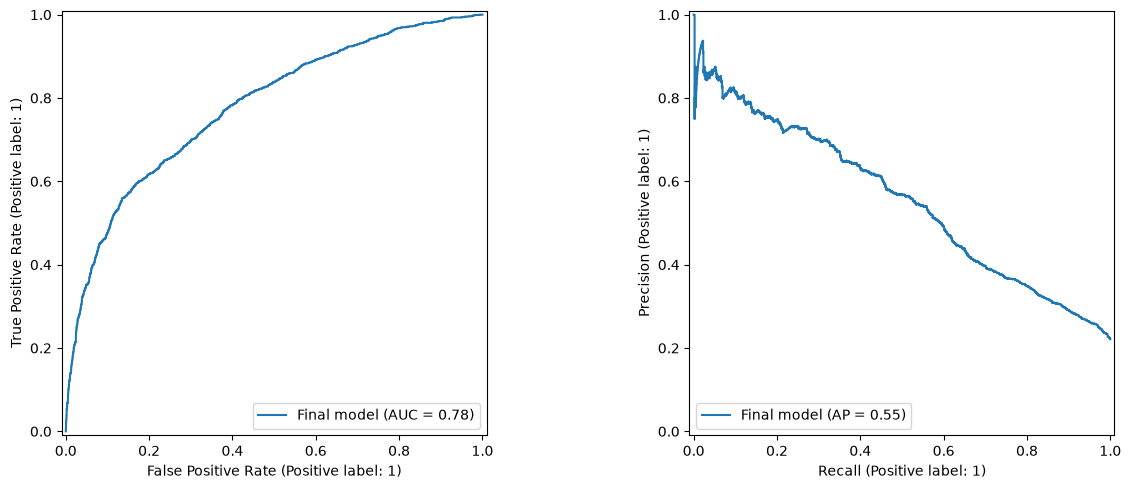

In [259]:
calibrated_model = CalibratedClassifierCV(
    estimator=clone(best_model),
    method='isotonic',
    cv=5,
    n_jobs=-1
)
calibrated_model.fit(X_train, y_train)
calibrated_metrics = evaluate_model(
    calibrated_model,
    X_test,
    y_test,
    threshold=chosen_threshold
)
display(pd.Series(calibrated_metrics).round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
RocCurveDisplay.from_predictions(y_test, test_probabilities, ax=axes[0], name='Final model')
PrecisionRecallDisplay.from_predictions(y_test, test_probabilities, ax=axes[1], name='Final model')
plt.tight_layout()
plt.show()

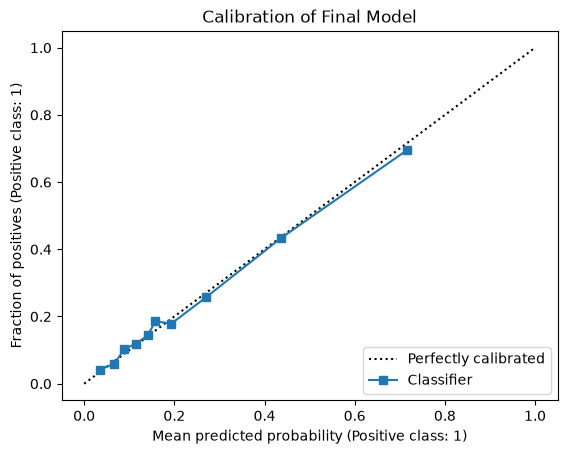

In [260]:
CalibrationDisplay.from_predictions(
    y_test,
    probability_scores(calibrated_model, X_test),
    n_bins=10,
    strategy='quantile'
)
plt.title('Calibration of Final Model')
plt.show()

In [261]:
print('Model reliability checks')
print(f'Cross-validation PR-AUC: {tuned_search.best_score_:.4f}')
print(f'Test PR-AUC: {tuned_metrics["pr_auc"]:.4f}')
print(f'Test ROC-AUC: {tuned_metrics["roc_auc"]:.4f}')
print(f'Test Brier score: {tuned_metrics["brier_score"]:.4f}')
print(f'Test recall: {tuned_metrics["recall"]:.4f}')
print(f'Test precision: {tuned_metrics["precision"]:.4f}')

Model reliability checks
Cross-validation PR-AUC: 0.5636
Test PR-AUC: 0.5540
Test ROC-AUC: 0.7789
Test Brier score: 0.1727
Test recall: 0.5441
Test precision: 0.5424


In [262]:
if tuned_metrics['pr_auc'] >= tuned_search.best_score_ - 0.05:
    print('The test PR-AUC is reasonably consistent with cross-validation.')
else:
    print('Warning: investigate possible distribution shift or overfitting.')

The test PR-AUC is reasonably consistent with cross-validation.


In [263]:
print('\nRecommended safeguards:')
print('- Keep preprocessing inside the modeling pipeline.')
print('- Use stratified cross-validation and PR-AUC for model selection.')
print('- Keep tree depth and leaf sizes constrained.')
print('- Tune thresholds only on validation data, never on the test set.')
print('- Reserve the test set for final unbiased evaluation.')
print('- Require human review before any financial decision.')


Recommended safeguards:
- Keep preprocessing inside the modeling pipeline.
- Use stratified cross-validation and PR-AUC for model selection.
- Keep tree depth and leaf sizes constrained.
- Tune thresholds only on validation data, never on the test set.
- Reserve the test set for final unbiased evaluation.
- Require human review before any financial decision.


In [265]:
import os
import pickle

model_path = r"C:\Users\USER\OneDrive\Desktop\AI-Financial-Risk-Intelligence\models\credit_default_model.pkl"

os.makedirs(os.path.dirname(model_path), exist_ok=True)

with open(model_path, "wb") as file:
    pickle.dump(
        {
            "model": final_model,
            "threshold": chosen_threshold,
        },
        file,
    )

print(f"Model saved successfully to: {model_path}")

Model saved successfully to: C:\Users\USER\OneDrive\Desktop\AI-Financial-Risk-Intelligence\models\credit_default_model.pkl
